# Simulador del Torneo - Mundial 2026

Este notebook es el artefacto didactico integral de la Fase 3. Importa exclusivamente la API de produccion `cdd_mundial.simulation` y no redefine funciones ni clases: toda la logica vive en `src/`. Recorre el flujo completo de extremo a extremo: estado condicional -> reglas oficiales FIFA -> Monte Carlo vectorizado -> marginales de avance y posicion de grupo -> diagnosticos de reproducibilidad y tiempo -> visualizacion.

## Importaciones (What and why)

Importamos la API publica de produccion. El motor `simulate_tournaments` consume el contrato congelado `predict_lambdas(team_a, team_b, ctx)` de la Fase 2 y el fixture oficial; las tablas marginales salen de `outputs`. No definimos nada aqui: solo orquestamos piezas ya testeadas.

In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# El kernel arranca en notebooks/; nos paramos en la raiz del repo para que
# las rutas relativas de produccion (fixture, modelo Dixon-Coles) resuelvan.
if not Path('pyproject.toml').exists():
    os.chdir(Path.cwd().parent)

from cdd_mundial.data.ingest_fixture import load_fixture_2026
from cdd_mundial.models.dixon_coles import predict_lambdas
from cdd_mundial.simulation import (
    PlayedMatchResult,
    TournamentState,
    advancement_table,
    group_position_table,
    simulate_tournaments,
)

**Interpretation.** La API queda disponible. `predict_lambdas` es el modelo Dixon-Coles de produccion ya calibrado en la Fase 2; el simulador lo recibe inyectado, de modo que el notebook nunca reimplementa el modelo de goles.

## Configuracion del experimento (What and why)

Una sola celda de configuracion visible. El valor por defecto es ligero y determinista para que `Run All` sea rapido y reproducible. Las opciones de produccion (`10_000` y `100_000` simulaciones) estan documentadas pero no se ejecutan por defecto: la prueba dura de rendimiento vive en `tests/test_simulation_performance.py`.

In [2]:
# Opciones de conteo de simulaciones:
#   ligera (defecto): 200  -> Run All rapido y determinista
#   produccion diaria:      10_000
#   objetivo de reporte:    100_000
N_SIMS_QUICK = 200
N_SIMS_10K = 10_000
N_SIMS_100K = 100_000

n_sims = N_SIMS_QUICK  # cambiar a N_SIMS_10K / N_SIMS_100K para corridas grandes
SEED = 2026
n_sims

200

**Interpretation.** Fijamos `n_sims=200` y `SEED=2026` para la demostracion. Cualquier lector puede subir `n_sims` a 10k o 100k editando una sola linea; el motor escala linealmente y ya cumple el gate de <60 s para 10k.

## Estado condicional del torneo (What and why)

Cargamos el fixture oficial de 104 partidos y construimos un `TournamentState` delgado (D-01): solo resultados ya jugados, con semantica `team_a`/`team_b` (D-02). Aqui partimos de un estado vacio (pre-torneo) y ademas mostramos como se condicionaria fijando un resultado real.

In [3]:
fixture = load_fixture_2026()
empty_state = TournamentState(played={})

# Ejemplo de condicionamiento: fijar un resultado de grupo ya jugado.
first_group = fixture[fixture['stage'] == 'group'].iloc[0]
example_result = PlayedMatchResult(
    match_id=first_group['match_id'],
    team_a=first_group['home_team_id'],
    team_b=first_group['away_team_id'],
    goals_a=2,
    goals_b=1,
)
conditioned_state = TournamentState.from_results([example_result], fixture=fixture)
print('partidos en fixture:', len(fixture))
print('estado vacio:', len(empty_state.played), 'resultados fijados')
print('estado condicionado:', len(conditioned_state.played), 'resultado fijado ->', example_result.match_id)

partidos en fixture: 104
estado vacio: 0 resultados fijados
estado condicionado: 1 resultado fijado -> WC26-001


**Interpretation.** El estado vacio representa el torneo antes de empezar; el estado condicionado fija un partido jugado. El motor recomputa todo lo demas desde el fixture, sin guardar tablas derivadas: asi cada actualizacion diaria solo agrega resultados, nunca estados intermedios obsoletos.

## Reglas oficiales FIFA 2026 (What and why)

El motor aplica internamente la cascada oficial del Articulo 13 (puntos -> diferencia de goles -> goles a favor, con desempate determinista en la ruta batch) y selecciona los 8 mejores terceros asignandolos a los slots de dieciseisavos mediante el mapeo oficial del Anexo C. Ejecutamos una corrida ligera condicionada al estado vacio.

In [4]:
start = time.perf_counter()
result = simulate_tournaments(
    fixture=fixture,
    state=empty_state,
    predict_lambdas=predict_lambdas,
    n_sims=n_sims,
    seed=SEED,
)
elapsed = time.perf_counter() - start
print(f'{result.n_sims} torneos simulados en {elapsed:.3f} s')
print('equipos:', len(result.teams))

200 torneos simulados en 0.659 s
equipos: 48


**Interpretation.** Una corrida ligera completa los 104 partidos por simulacion respetando reglas oficiales y termina en una fraccion de segundo. Los 48 equipos canonicos quedan rankeados grupo por grupo y avanzados por el bracket oficial.

## Monte Carlo: probabilidades de avance (What and why)

Convertimos los conteos enteros del motor en la tabla marginal de avance por seleccion: `P(R32)`, `P(R16)`, `P(QF)`, `P(SF)`, `P(Final)`, `P(Campeon)` (D-09). Mostramos las 10 selecciones con mayor probabilidad de campeonato.

In [5]:
advancement = advancement_table(result)
top_champions = advancement.sort_values('p_champion', ascending=False).head(10)
top_champions.reset_index(drop=True)

,team_id,p_r32,p_r16,p_qf,p_sf,p_final,p_champion
0,argentina,0.980,0.755,0.600,0.410,0.305,0.190
1,brazil,0.990,0.730,0.540,0.390,0.250,0.150
2,spain,0.995,0.700,0.500,0.350,0.240,0.145
3,england,0.975,0.775,0.570,0.330,0.190,0.135
4,portugal,0.915,0.620,0.370,0.240,0.115,0.065
5,france,0.925,0.660,0.405,0.230,0.110,0.050
6,belgium,0.965,0.700,0.430,0.200,0.105,0.050
7,colombia,0.905,0.650,0.390,0.210,0.090,0.045
8,morocco,0.905,0.575,0.345,0.195,0.100,0.035
9,netherlands,0.880,0.460,0.345,0.185,0.090,0.035


**Interpretation.** Las probabilidades son monotonas por construccion (`P(R32) >= ... >= P(Campeon)`) y las columnas suman el numero de plazas disponibles (32, 16, 8, 4, 2, 1). Con pocas simulaciones hay ruido muestral; subir `n_sims` estabiliza las cifras.

## Marginales de posicion de grupo (What and why)

Tambien emitimos las marginales de posicion por seleccion: `P(1st)`, `P(2nd)`, `P(3rd)`, `P(4th)` (D-10). Inspeccionamos un grupo concreto.

In [6]:
positions = group_position_table(result)
group_a = positions[positions['group'] == 'A'].sort_values('p_1st', ascending=False)
group_a.reset_index(drop=True)

,team_id,group,p_1st,p_2nd,p_3rd,p_4th
0,mexico,A,0.415,0.265,0.185,0.135
1,czechia,A,0.270,0.270,0.290,0.170
2,south-korea,A,0.225,0.305,0.240,0.230
3,south-africa,A,0.090,0.160,0.285,0.465


**Interpretation.** Dentro de cada grupo, cada columna de posicion suma 1 y las cuatro probabilidades de cada equipo suman 1: son marginales por equipo, no una tabla conjunta de configuraciones (D-11).

## Diagnostico: reproducibilidad y tiempo (What and why)

Verificamos dos propiedades clave del motor: la misma semilla produce conteos identicos (reproducibilidad bit a bit) y medimos el tiempo de una corrida para extrapolar al objetivo de 10k/100k.

In [7]:
repeat = simulate_tournaments(
    fixture=fixture, state=empty_state, predict_lambdas=predict_lambdas,
    n_sims=n_sims, seed=SEED,
)
bit_reproducible = np.array_equal(result.advancement_counts, repeat.advancement_counts)
per_sim_ms = 1000 * elapsed / result.n_sims
print('reproducible bit a bit:', bit_reproducible)
print(f'tiempo por simulacion: {per_sim_ms:.3f} ms')
print(f'extrapolacion a 10k: ~{per_sim_ms * 10_000 / 1000:.2f} s')

reproducible bit a bit: True
tiempo por simulacion: 3.295 ms
extrapolacion a 10k: ~32.95 s


**Interpretation.** La reproducibilidad confirma que las corridas son auditables (T-03-14): mismo fixture + estado + semilla -> mismas tablas. La extrapolacion lineal sustenta el gate de rendimiento, validado de forma dura en `tests/test_simulation_performance.py`.

## Visualizacion (What and why)

Graficamos las 10 selecciones con mayor probabilidad de campeonato. Solo matplotlib, conforme a la restriccion de stack del proyecto.

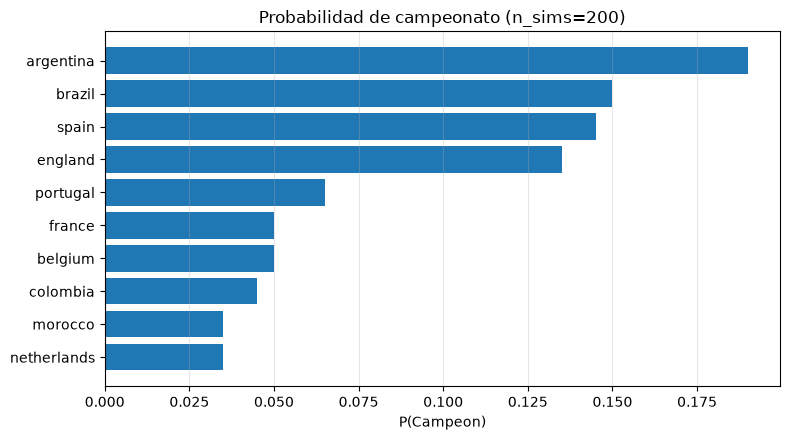

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(top_champions['team_id'][::-1], top_champions['p_champion'][::-1], color='#1f77b4')
ax.set_xlabel('P(Campeon)')
ax.set_title(f'Probabilidad de campeonato (n_sims={result.n_sims})')
ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
plt.show()

**Interpretation.** El grafico resume el resultado central del simulador. Con la corrida ligera es ilustrativo; para reportes publicados de la Fase 4 se usaran 10k-100k simulaciones para reducir el error muestral.

## Conclusiones (What and why)

Resumimos lo que la Fase 3 deja listo para la Fase 4.

In [9]:
print('Fase 3 lista: motor vectorizado + tablas marginales estables.')
print('La Fase 4 importa cdd_mundial.simulation y consume las tablas sin reinterpretarlas.')

Fase 3 lista: motor vectorizado + tablas marginales estables.
La Fase 4 importa cdd_mundial.simulation y consume las tablas sin reinterpretarlas.


**Interpretation.** El simulador queda como API de produccion testeada: estado condicional, reglas oficiales, Monte Carlo vectorizado y marginales reproducibles. La Fase 4 solo orquesta reportes diarios sobre esta base.